In [1]:
import sys
sys.path.append("..")

In [2]:
from services.preprocessing import binary_encoder

In [3]:
import joblib

pipeline = joblib.load("../models/churn_prediction.pkl")

In [4]:
pipeline.named_steps.keys()

dict_keys(['preprocessor', 'model'])

In [5]:
pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]

In [7]:
import pandas as pd
raw_df = pd.read_csv("../datsets/raw_dataset/Telco-Customer-Churn.csv")
df = raw_df.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
y = df["Churn"].map({"Yes": 1, "No": 0})

In [10]:
df.drop(["customerID", "Churn"], axis=1, inplace=True)

In [11]:
X = df

In [12]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [13]:
X_train,X_val,y_train,y_val = train_test_split(
    X_temp,y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

In [14]:
X_test_processed = preprocessor.transform(X_test)

In [15]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
binary_features = ["gender", "Partner", "Dependents", "PhoneService",  "PaperlessBilling",]
categorical_features = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

In [16]:
ohe = preprocessor.named_transformers_["cat"]\
                  .named_steps["ohe"]

cat_names = ohe.get_feature_names_out(categorical_features)

In [17]:
feature_names = (
    numeric_features
    + binary_features
    + list(cat_names)
)

In [18]:
feature_names

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'MultipleLines_No',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Bank transfer (automatic)',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mail

In [19]:
print(len(feature_names))
print(X_test_processed.shape)

40
(1409, 40)


In [20]:
len(feature_names) == X_test_processed.shape[1]

True

In [23]:
import sys

!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 3.7 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 3.4 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.7 MB 3.5 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 3.7 MB/s eta 0:00:10
   - -------------------------------------- 1.3/38.1 MB 3.5 MB/s eta 0:00:11
   -- ------------------------------------- 2.1/38.1 MB 3.6 MB/s eta 0:00:11

In [24]:
import shap
explainer = shap.LinearExplainer(
    model,
    X_test_processed
)

d:\Anaconda3\envs\torchgpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
shap_values = explainer.shap_values(X_test_processed)

In [26]:
print(shap_values.shape)

(1409, 40)


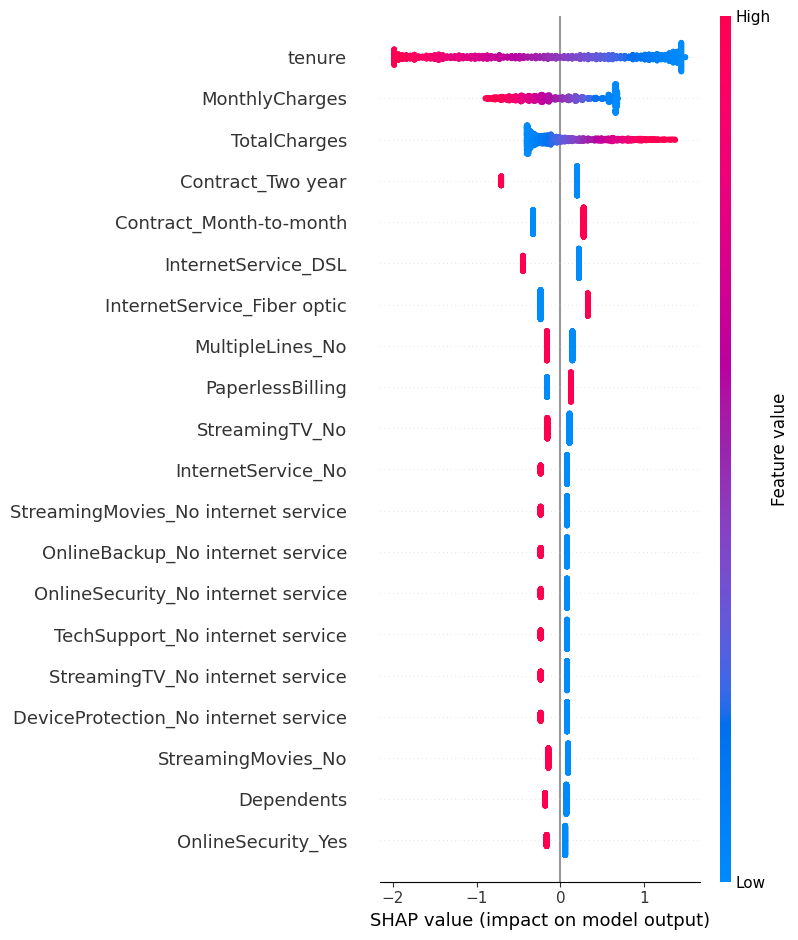

In [27]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

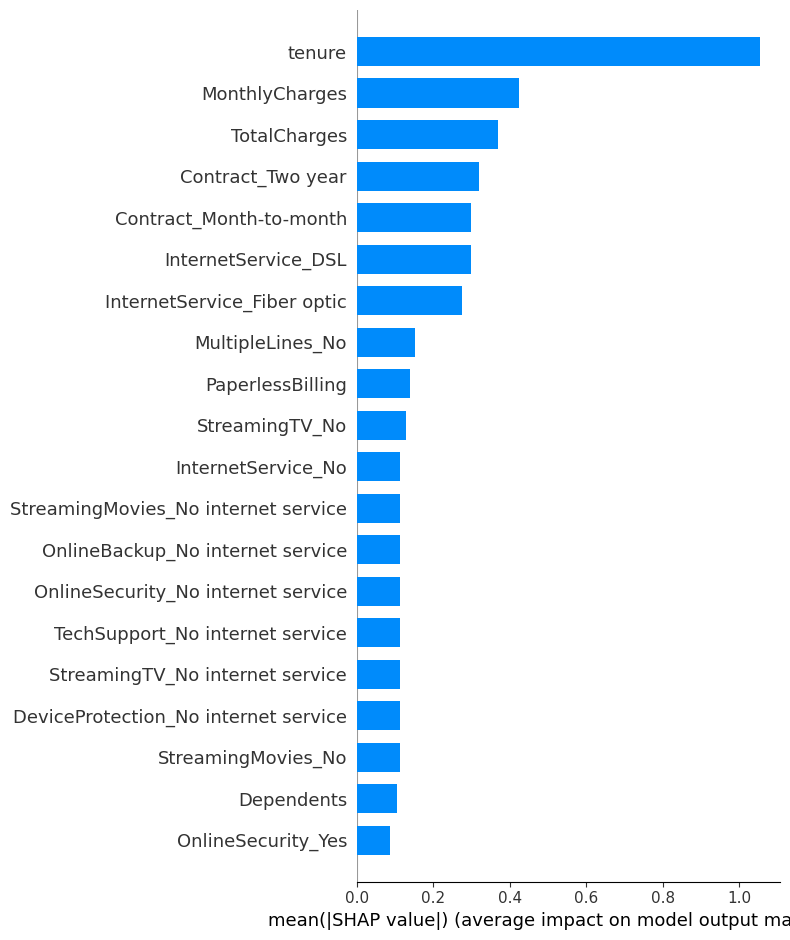

In [28]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

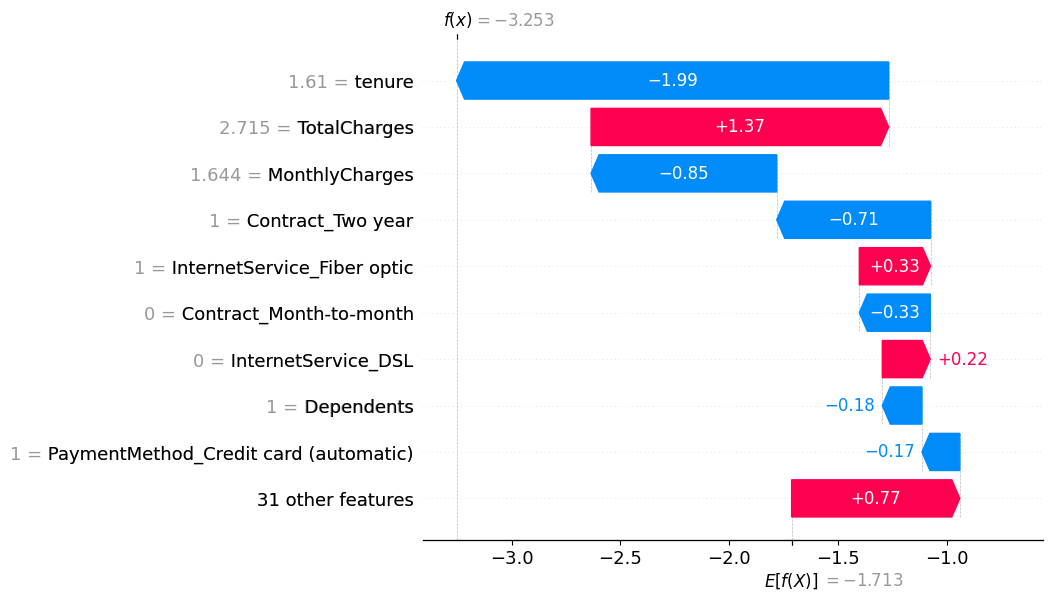

In [29]:
customer_idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_test_processed[customer_idx],
        feature_names=feature_names
    )
)

In [31]:
import matplotlib.pyplot as plt

In [33]:
plt.savefig("../reports/shap_summary.png", bbox_inches="tight")
plt.savefig("../reports/shap_bar.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>